# Comparisons with BGEP ULS sea ice draft estimates updated with new data

**Summary:** In this notebook, we produce comparisons of the gridded ICESat-2 sea ice thickness data with draft measurements obtained from Upward Looking Sonar moorings deployed in the Beaufort Sea. 

 
**Version history**: Version 1 (01/01/2022)
 

# Import notebook dependencies

In [22]:
import xarray as xr 
import pandas as pd
import numpy as np
import itertools
import pyproj 
from netCDF4 import Dataset
import scipy.interpolate 
from utils.read_data_utils import read_book_data, read_IS2SITMOGR4 # Helper function for reading the data from the bucket
from utils.plotting_utils import compute_gridcell_winter_means, interactiveArcticMaps, interactive_winter_mean_maps, interactive_winter_comparison_lineplot # Plotting
from scipy import stats
import datetime
# Plotting dependencies
import cartopy.crs as ccrs
from textwrap import wrap
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh # Helps avoid some weird issues with the polar projection 
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

# Interpolating/smoothing packages 
from scipy.interpolate import griddata
from scipy.spatial import KDTree
from astropy.convolution import convolve
from astropy.convolution import Gaussian2DKernel

mpl.rcParams['figure.dpi'] = 200 # Sets figure size in the notebook

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 


In [23]:
grid_size=25
ib_agg_str='mean'


# Define the variables to compare
variables_ice = [
    'ice_thickness',
    'ice_thickness_sm', 
    'ice_thickness_mw99', 
    'ice_thickness_j22', 
    'cs2_sea_ice_thickness_UBRIS'
]

# Define the variables to compare
variables_snow = [
    'snow_depth', 
    'snow_depth_sm', 
    'snow_depth_mw99', 
]

variables_all = variables_ice+variables_snow

In [24]:
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 
IS2SITMOGR4_v3


load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr
<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
    longitude                       (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density        

<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_sm                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [25]:
out_proj = 'EPSG:3411'
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

mapProj = pyproj.Proj("+init=" + out_proj)
xptsIS2, yptsIS2 = mapProj(out_lons, out_lats)

In [26]:
def getCS2ubris(mapProj, dataPathCS2, dataset):
    """ Read in the University of Bristol CryoSat-2 sea ice thickness data

    
    Args:
        dataPathCS2 (str): location of data
        
    Returns
        xptsT (2d numpy array): x coordinates on our map projection
        yptsT (2d numpy array): y coordinates on our map projection
        thicknessCS (2d numpy array): monthly sea ice thickness estimates
        

    """
    ubris_f = xr.open_dataset(dataPathCS2+dataset, decode_times=False)

    # Issue with time starting from year 0!
    # Re-set it to start from some other year
    ubris_f = ubris_f.rename({'Time':'time'})
    ubris_f['time'] = ubris_f['time']-679352
    ubris_f.time.attrs["units"] = "days since 1860-01-01"
    decoded_time = xr.decode_cf(ubris_f)

    ubris_f['time']=decoded_time.time
    ubris_f = ubris_f.swap_dims({'t': 'time'})

    # Resample to monthly, note that the S just makes the index start on the 1st of the month
    thicknessCS = ubris_f.resample(time="MS").mean()
    xptsT, yptsT = mapProj(thicknessCS.isel(time=0).Longitude, thicknessCS.isel(time=0).Latitude)
    
    return xptsT, yptsT, thicknessCS

def regridToICESat2(dataArrayNEW, xptsNEW, yptsNEW, xptsIS2, yptsIS2):  
    """ Regrid new data to ICESat-2 grid 
    
    Args: 
        dataArrayNEW (xarray DataArray): Numpy variable array to be gridded to ICESat-2 grid 
        xptsNEW (numpy array): x-values of dataArrayNEW projected to ICESat-2 map projection 
        yptsNEW (numpy array): y-values of dataArrayNEW projected to ICESat-2 map projection 
        xptsIS2 (numpy array): ICESat-2 longitude projected to ICESat-2 map projection
        yptsIS2 (numpy array): ICESat-2 latitude projected to ICESat-2 map projection
    
    Returns: 
        gridded (numpy array): data regridded to ICESat-2 map projection
    
    """
    #gridded = []
    #for i in range(len(dataArrayNEW.values)): 
    gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    try:
        gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    except:
        try:
            gridded = scipy.interpolate.griddata((xptsNEW,yptsNEW), dataArrayNEW, (xptsIS2, yptsIS2), method = 'nearest')
        except:
            print('Error interpolating..')
    
    return gridded

def regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range, dataPathCS2='/home/jovyan/Data/CS2/UIT/', dataset='ubristol_cryosat2_seaicethickness_nh_80km_v1p7.nc'):

    cs2_ubris = []
    valid_dates=[]

    xptsT_ubris, yptsT_ubris, cs2_ubris_raw = getCS2ubris(mapProj, dataPathCS2, dataset)
    
    for date in date_range:
        
            
        try:
            cs2_ubris_temp_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Thickness.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 
            ice_conc_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Concentration.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2)     
            #cs2_ubris_temp_is2grid[ice_conc_is2grid<0.5]=np.nan
            
            cs2_ice_type_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Type.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 

            
        except:
            print(date)
            print('no CS-2 data or issue with gridding, so skipping...')
            continue
        valid_dates.append(date)

        #cs2_ubris_temp_is2grid_xr = xr.DataArray(data = cs2_ubris_temp_is2grid, 
        #                        dims = ['y', 'x'], 
        #                        coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)}, 
        #                        name = 'cs2_sea_ice_thickness_UBRIS')

        cs2_ubris_temp_is2grid_xr = xr.Dataset({'cs2_sea_ice_thickness_UBRIS': (('y', 'x'), cs2_ubris_temp_is2grid), 
                                'cs2_sea_ice_type_UBRIS': (('y', 'x'), cs2_ice_type_is2grid)}, 
                                coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)} 
                                )
        
        cs2_ubris.append(cs2_ubris_temp_is2grid_xr)

    cs2_ubris = xr.concat(cs2_ubris, 'time')
    #cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris_attrs = {'units': 'meters', 'long_name': 'University of Bristol CryoSat-2 Arctic sea ice thickness', 'data_download': 'https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01613', 
            'download_date': '09-2022', 'citation': 'Landy, J.C., Dawson, G.J., Tsamados, M. et al. A year-round satellite sea-ice thickness record from CryoSat-2. Nature 609, 517–522 (2022). https://doi.org/10.1038/s41586-022-05058-5'} 
    cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris = cs2_ubris.assign_attrs(cs2_ubris_attrs)  

    return cs2_ubris




start_date_cs2 = "Nov 2018"
end_date_cs2 = "July 2021"
# MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

cs2_ubris = regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2='/Users/akpetty/Data/CS2/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')

IS2SITMOGR4_v3 = IS2SITMOGR4_v3.merge(cs2_ubris)

In [27]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3.sel(time='2019-04-01')

In [28]:


# Interpolation settings 
method = "linear" 

# Create a new dataset to store the interpolated values
IS2SITMOGR4_v3_int = xr.Dataset()
for var in variables_all:
    # Perform linear interpolation 
    is2_to_interp = IS2SITMOGR4_v3[var].values.copy()
    is2_to_interp[np.where(IS2SITMOGR4_v3.sea_ice_conc<0.15)] = 0 # Set 15% conc or less to 0 thickness
    np_interpolated = griddata((xptsIS2[(np.isfinite(is2_to_interp))], 
                                yptsIS2[(np.isfinite(is2_to_interp))]), 
                                is2_to_interp[(np.isfinite(is2_to_interp))].flatten(),
                                (xptsIS2, yptsIS2), 
                                fill_value=np.nan,
                                method=method)
    np_interpolated[~(np.isfinite(IS2SITMOGR4_v3.sea_ice_conc))]=np.nan # Remove thickness data where cdr data is nan 
    np_interpolated[np.where(IS2SITMOGR4_v3.sea_ice_conc<0.5)]=np.nan # Remove thickness data where cdr data < 50% concentration

    x_stddev=0.5
    kernel = Gaussian2DKernel(x_stddev=x_stddev)
    np_interpolated_gauss = convolve(np_interpolated, kernel)
    np_interpolated_gauss[~(np.isfinite(IS2SITMOGR4_v3.sea_ice_conc))]=np.nan # Remove thickness data where cdr data is nan 
    np_interpolated_gauss[np.where(IS2SITMOGR4_v3.sea_ice_conc<0.5)]=np.nan # Remove thickness data where cdr data < 50% concentration

    # Add the interpolated data to the new dataset
    IS2SITMOGR4_v3_int[var] = (('y', 'x'), np_interpolated_gauss)

# Add latitude and longitude coordinates to the new dataset
IS2SITMOGR4_v3_int = IS2SITMOGR4_v3_int.assign_coords({
    'latitude': (('y', 'x'), IS2SITMOGR4_v3.latitude.values),
    'longitude': (('y', 'x'), IS2SITMOGR4_v3.longitude.values)
})

In [29]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3_int
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                      (y: 448, x: 304)
Coordinates:
    latitude                     (y, x) float32 31.1 31.2 31.3 ... 34.58 34.47
    longitude                    (y, x) float32 168.3 168.1 ... -10.18 -9.999
Dimensions without coordinates: y, x
Data variables:
    ice_thickness                (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_sm             (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_mw99           (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_j22            (y, x) float64 nan nan nan nan ... nan nan nan
    cs2_sea_ice_thickness_UBRIS  (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth                   (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth_sm                (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth_mw99              (y, x) float64 nan nan nan nan ... nan nan nan

In [30]:
# COARSEN TO MATCH 100 KM RESOLUTION OF IB
if grid_size==100:
    IS2SITMOGR4_v3 = IS2SITMOGR4_v3.coarsen(y=4, x=4, boundary='trim').mean()
    IS2SITMOGR4_v3

In [31]:
# Open the NetCDF file
# Replace 'path/to/your/file.nc' with the actual path to your NetCDF file
file_path = '/Users/akpetty/Data/IS2-obs-comparison-data/icebird_on_is2_grid_'+str(grid_size)+'km_test1.nc'
dataset = xr.open_dataset(file_path)
dataset = dataset.rename({'date': 'time'})
dataset = dataset.transpose('y', 'x', 'time')
# Display the dataset
print(dataset)

<xarray.Dataset>
Dimensions:                   (x: 304, y: 448, time: 5)
Coordinates:
    lon                       (y, x) float64 ...
    lat                       (y, x) float64 ...
  * x                         (x) float64 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                         (y) float64 5.838e+06 5.812e+06 ... -5.338e+06
  * time                      (time) datetime64[ns] 2019-04-02 ... 2019-04-10
    crs                       int32 ...
Data variables:
    sea_ice_thickness_mean    (y, x, time) float64 ...
    sea_ice_thickness_median  (y, x, time) float64 ...
    sea_ice_thickness_mode    (y, x, time) float64 ...
    sea_ice_thickness_count   (y, x, time) float64 ...
    snow_thickness_mean       (y, x, time) float64 ...
    snow_thickness_median     (y, x, time) float64 ...
    snow_thickness_mode       (y, x, time) float64 ...
    snow_thickness_count      (y, x, time) float64 ...


In [32]:
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                      (y: 448, x: 304)
Coordinates:
    latitude                     (y, x) float32 31.1 31.2 31.3 ... 34.58 34.47
    longitude                    (y, x) float32 168.3 168.1 ... -10.18 -9.999
Dimensions without coordinates: y, x
Data variables:
    ice_thickness                (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_sm             (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_mw99           (y, x) float64 nan nan nan nan ... nan nan nan
    ice_thickness_j22            (y, x) float64 nan nan nan nan ... nan nan nan
    cs2_sea_ice_thickness_UBRIS  (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth                   (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth_sm                (y, x) float64 nan nan nan nan ... nan nan nan
    snow_depth_mw99              (y, x) float64 nan nan nan nan ... nan nan nan

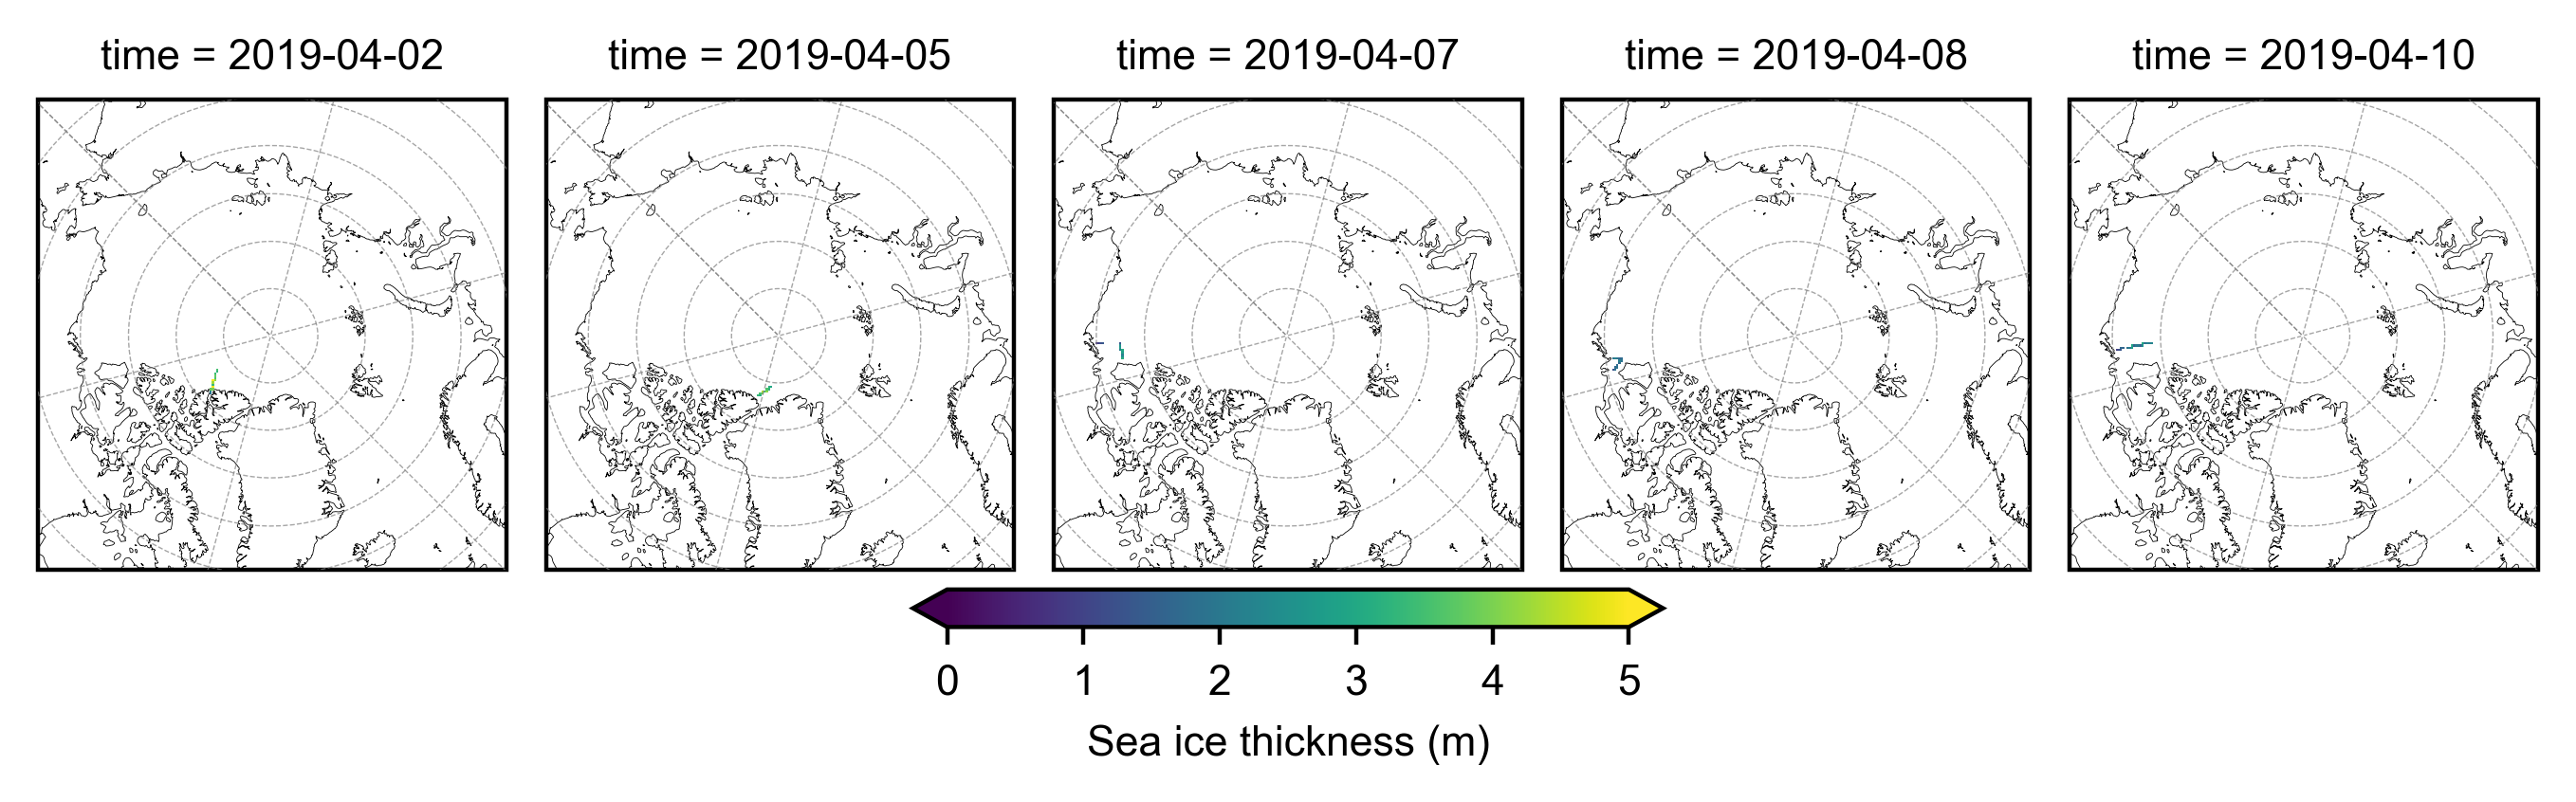

In [33]:

fig_width=6.8
fig_height=5.4

im1 = dataset.sea_ice_thickness_mean.plot(x="lon", y="lat", col='time', transform=ccrs.PlateCarree(), 
                       cmap="viridis", zorder=3, add_labels=False,
                       subplot_kws={'projection':ccrs.NorthPolarStereo(central_longitude=-45)},
                       cbar_kwargs={'pad':0.01,'shrink': 0.3,'extend':'both', 
                                  'label':'Sea ice thickness (m)', 'location':'bottom'},
                       vmin=0, vmax=5,
                       figsize=(fig_width, fig_height))


# Add map features to all subplots
i=0
for i, ax in enumerate(im1.axes.flatten()):
    ax.coastlines(linewidth=0.15, color='black', zorder=2)
    #ax.add_feature(cfeature.LAND, color='0.95', zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=3)
    ax.set_extent([-179, 179, 65, 90], crs=ccrs.PlateCarree())
    #ax.text(0.02, 0.93, panel_letters[i], transform=ax.transAxes, fontsize=7, va='bottom', ha='left')
    #ax.set_title('', fontsize=8)
    i+=1

#plt.subplots_adjust(wspace=0.01) 
#plt.savefig('./figs/maps_summer_thickness_comparison.png', dpi=300, facecolor="white")
plt.show()
plt.close()

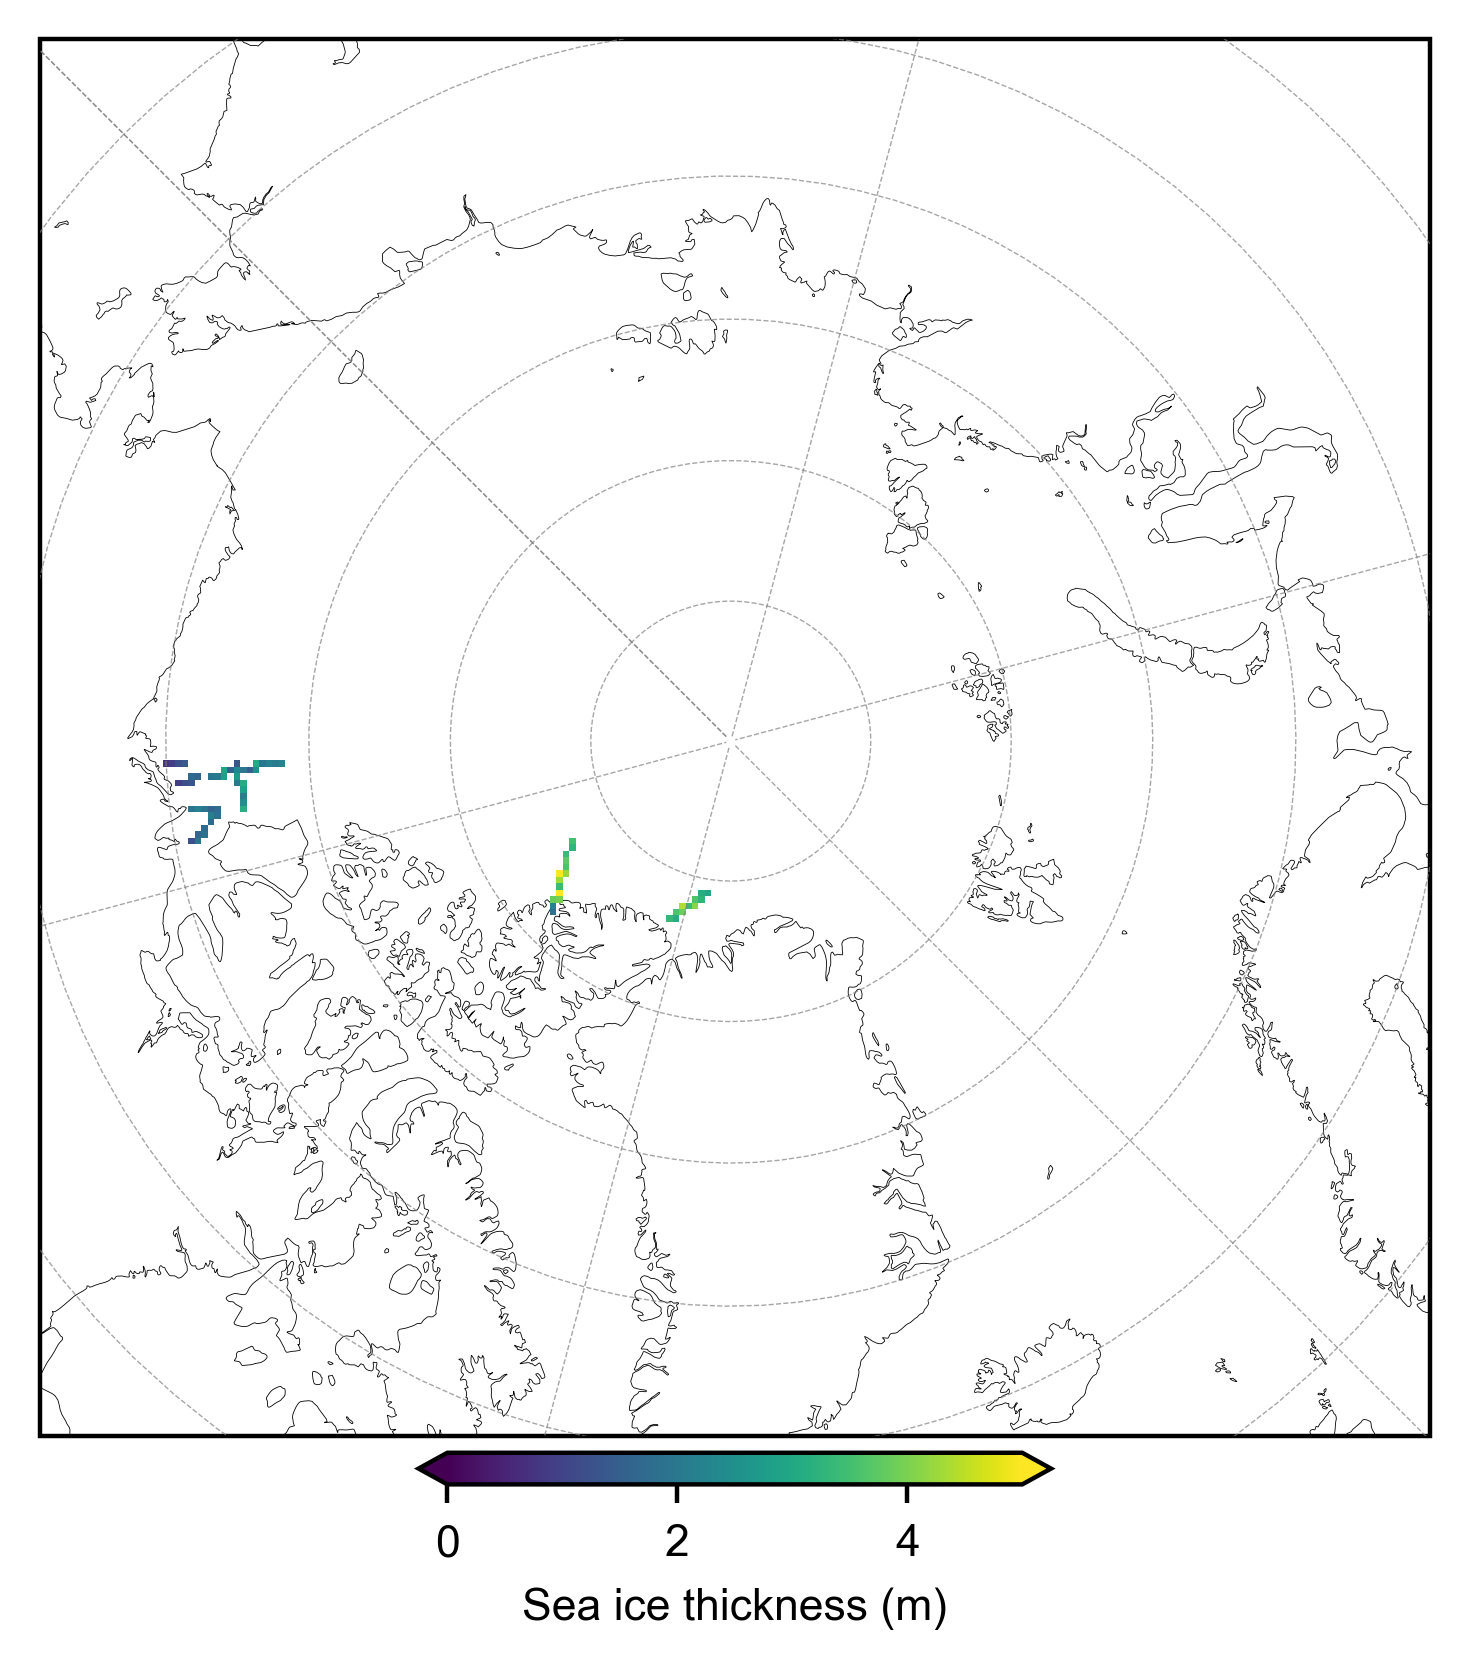

In [34]:

fig_width=6.8
fig_height=5.4

im1 = dataset.sea_ice_thickness_mean.mean(dim='time').plot(x="lon", y="lat",  transform=ccrs.PlateCarree(), 
                       cmap="viridis", zorder=3, add_labels=False,
                       subplot_kws={'projection':ccrs.NorthPolarStereo(central_longitude=-45)},
                       cbar_kwargs={'pad':0.01,'shrink': 0.3,'extend':'both', 
                                  'label':'Sea ice thickness (m)', 'location':'bottom'},
                       vmin=0, vmax=5,
                       figsize=(fig_width, fig_height))

# Add map features to the single subplot
ax = im1.axes  # Access the single axis object
ax.coastlines(linewidth=0.15, color='black', zorder=2)
ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=3)
ax.set_extent([-179, 179, 65, 90], crs=ccrs.PlateCarree())
#plt.subplots_adjust(wspace=0.01) 
plt.savefig('./figs/IBmap_all'+str(grid_size)+'km.png', dpi=300, facecolor="white")
plt.show()
plt.close()

In [35]:
dataset

<xarray.Dataset>
Dimensions:                   (x: 304, y: 448, time: 5)
Coordinates:
    lon                       (y, x) float64 ...
    lat                       (y, x) float64 ...
  * x                         (x) float64 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                         (y) float64 5.838e+06 5.812e+06 ... -5.338e+06
  * time                      (time) datetime64[ns] 2019-04-02 ... 2019-04-10
    crs                       int32 ...
Data variables:
    sea_ice_thickness_mean    (y, x, time) float64 ...
    sea_ice_thickness_median  (y, x, time) float64 ...
    sea_ice_thickness_mode    (y, x, time) float64 ...
    sea_ice_thickness_count   (y, x, time) float64 ...
    snow_thickness_mean       (y, x, time) float64 ...
    snow_thickness_median     (y, x, time) float64 ...
    snow_thickness_mode       (y, x, time) float64 ...
    snow_thickness_count      (y, x, time) float64 ...

In [36]:



# Initialize a dictionary to store validation results
validation_results = {}

# Calculate statistics and generate scatter plots for each variable
for var in variables_ice:
    # Calculate statistics
    IS2_var = IS2SITMOGR4_v3[var]
    IB_var = dataset['sea_ice_thickness_'+ib_agg_str].mean(dim='time') 
    IB_lon = dataset['lon']  
    valid_mask = ~np.isnan(IS2_var.values) & ~np.isnan(IB_var.values)
    IB_comps=IB_var.where(valid_mask).values.flatten()[~np.isnan(IB_var.where(valid_mask).values.flatten())]
    IB_lon=IB_lon.where(valid_mask).values.flatten()[~np.isnan(IB_var.where(valid_mask).values.flatten())]*-1.
    IS2_comps=IS2_var.where(valid_mask).values.flatten()[~np.isnan(IS2_var.where(valid_mask).values.flatten())]

    # Correlation Coeff
    correlation = '%.02f' % (np.corrcoef(IS2_comps, IB_comps)[0, 1])
    # Calculate mean bias
    mean_bias = '%.02f' % (np.mean(IS2_comps - IB_comps))
    # Calculate standard dev of differences
    std_dev = '%.02f' % (np.std(IS2_comps - IB_comps))
    # Calculate RMSE    
    rmse = '%.02f' % (np.sqrt(np.mean((IS2_comps - IB_comps) ** 2)))
    
    # Store results
    validation_results[var] = {
        'r_str': correlation, 'mb_str': mean_bias, 'sd_str': std_dev, 
        'rmse': rmse, 'IB_comps': IB_comps, 'IS2_comps': IS2_comps,
        'IB_lon': IB_lon
    }

# Print validation results
print(validation_results)

{'ice_thickness': {'r_str': '0.73', 'mb_str': '0.03', 'sd_str': '1.33', 'rmse': '1.33', 'IB_comps': array([0.73416306, 0.91414528, 1.21611728, 1.38616259, 1.33583568,
       3.0204772 , 1.93318028, 2.22606366, 2.06051877, 2.26073723,
       2.93433353, 1.55487528, 2.28648528, 1.97537913, 1.4844763 ,
       2.4952963 , 1.68103248, 1.60913671, 1.91573577, 2.02489574,
       2.78945771, 2.74967608, 0.91814694, 1.20431867, 1.31682411,
       1.99337231, 3.08443821, 2.81557322, 2.15178505, 2.49001974,
       1.94523891, 2.19834752, 1.94383033, 1.60093936, 1.75156833,
       3.14286031, 2.13732968, 1.87778065, 1.69826966, 1.71906675,
       1.69024859, 1.87237824, 1.21529962, 1.96244262, 3.49809066,
       3.27976989, 3.39387525, 3.75805811, 3.58882883, 5.49732484,
       4.21180687, 4.29279921, 3.39384525, 5.01003697, 3.12989524,
       2.98259387, 3.83834743, 3.95294155, 3.60988401, 3.2522433 ,
       2.15640955, 4.41373684, 3.38385622, 4.11487375, 1.84425494,
       3.58281022, 3.88600183

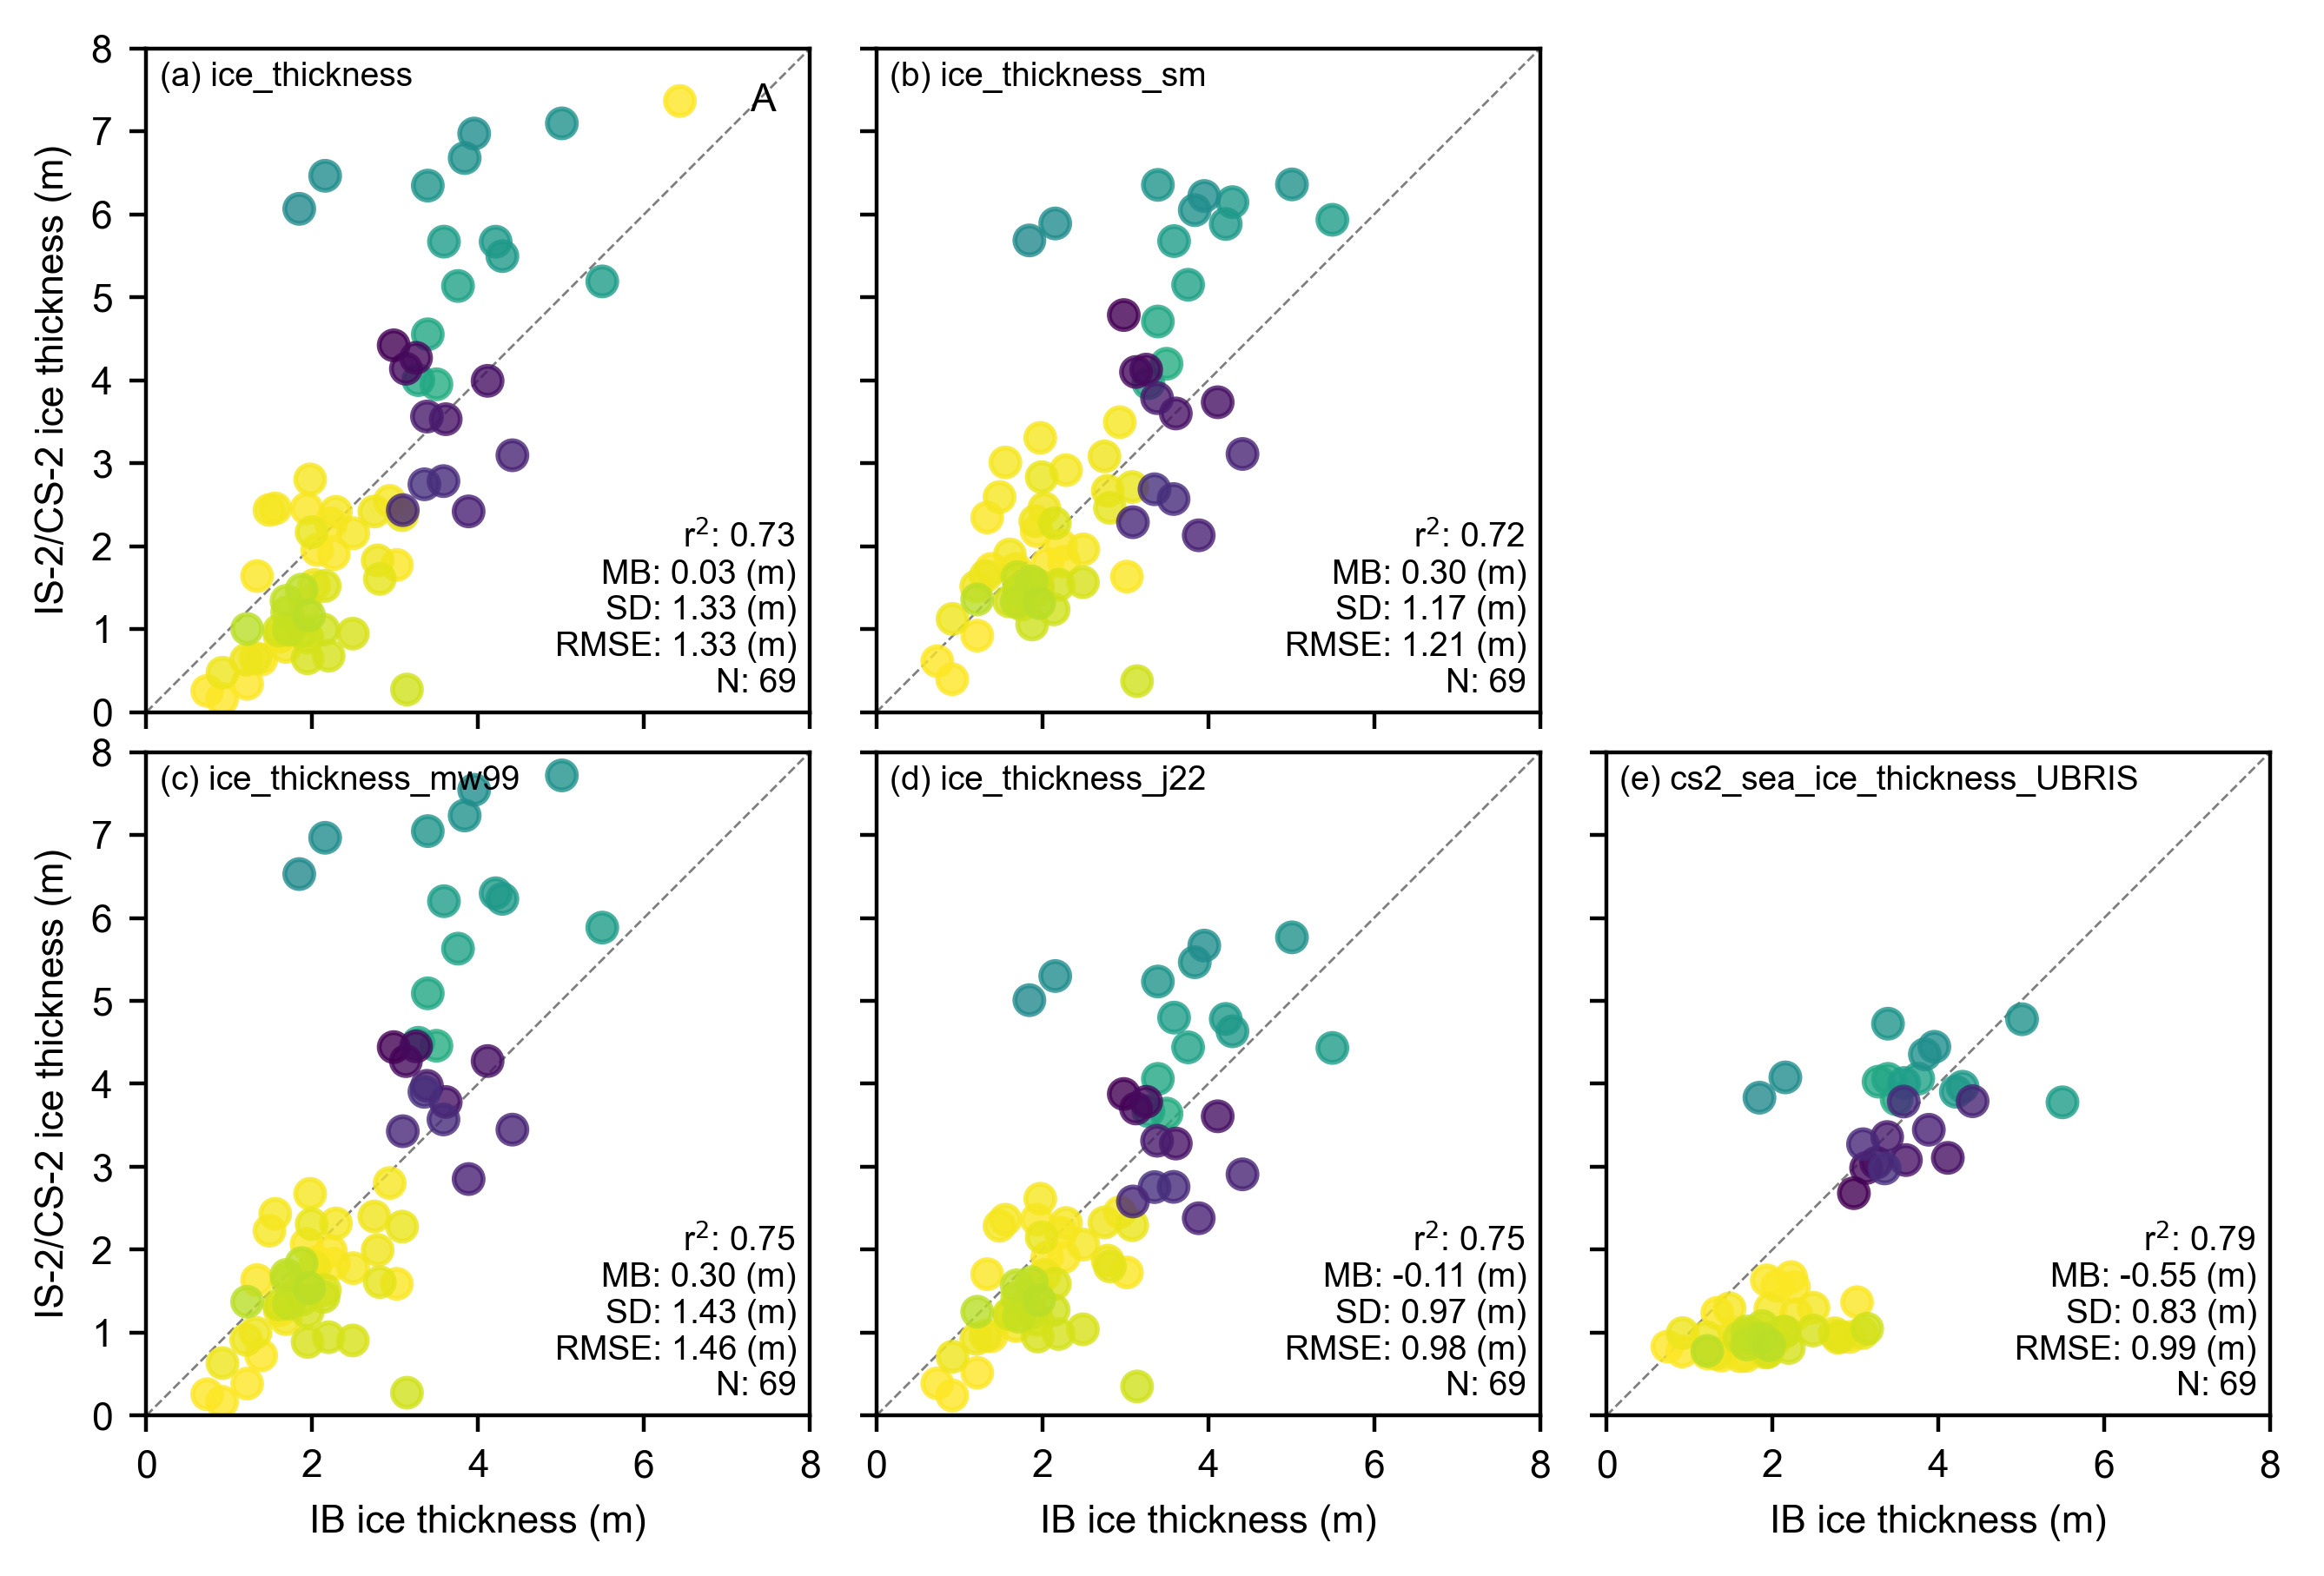

In [37]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

fig, axes = plt.subplots(2, 3, figsize=(6.8, 6.8*0.65), gridspec_kw={'hspace': 0.06, 'wspace': 0.04})  # Adjust hspace and wspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']  # Panel labels

# Leave the third subplot on the top row empty
axes[2].axis('off')

for i, option in enumerate(variables_ice):
    ax = axes[i if i < 2 else i + 1]  # Skip the third subplot on the top row
    #ax = axes[i]  # Skip the third subplot on the top row
    im = ax.scatter(validation_results[option]['IB_comps'], validation_results[option]['IS2_comps'], c=validation_results[option]['IB_lon'], alpha=0.8, label='A')

    # Retrieve validation results for the current option
    r_str= validation_results[option]['r_str']
    mb_str = validation_results[option]['mb_str']
    sd_str = validation_results[option]['sd_str']
    n_str =  str(len(validation_results[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results[option]['rmse']

    # Annotate the plot with RMSE, mean bias, and standard deviation
    #ax.annotate(f"A  r$^2$: {r_str_a}  MB: {mb_str_a} (m) SD: {sd_str_a} (m)  RMSE: {rmse_a:.02f} (m)", color='b', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"B  r$^2$: {r_str_b}  MB: {mb_str_b} (m) SD: {sd_str_b} (m)  RMSE: {rmse_b:.02f} (m)", color='tab:red', xy=(0.02, 0.92), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"D  r$^2$: {r_str_d}  MB: {mb_str_d} (m) SD: {sd_str_d} (m)  RMSE: {rmse_d:.02f} (m)", color='tab:orange', xy=(0.02, 0.86), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option, xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (i==0):
        ax.legend(frameon=False, loc="upper right")
    if (i == 0)|(i==2):
        ax.set_ylabel('IS-2/CS-2 ice thickness (m)')
    else:
        ax.set_yticklabels('')
    if i >= 2:
        ax.set_xlabel('IB ice thickness (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 8])
    ax.set_ylim([0, 8])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.legend()

#plt.tight_layout()
plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.09)  # Adjust these values to reduce whitespace


#plt.savefig('./figs/IB_scatter_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km.pdf', dpi=300)
plt.show()

# ... existing code ...

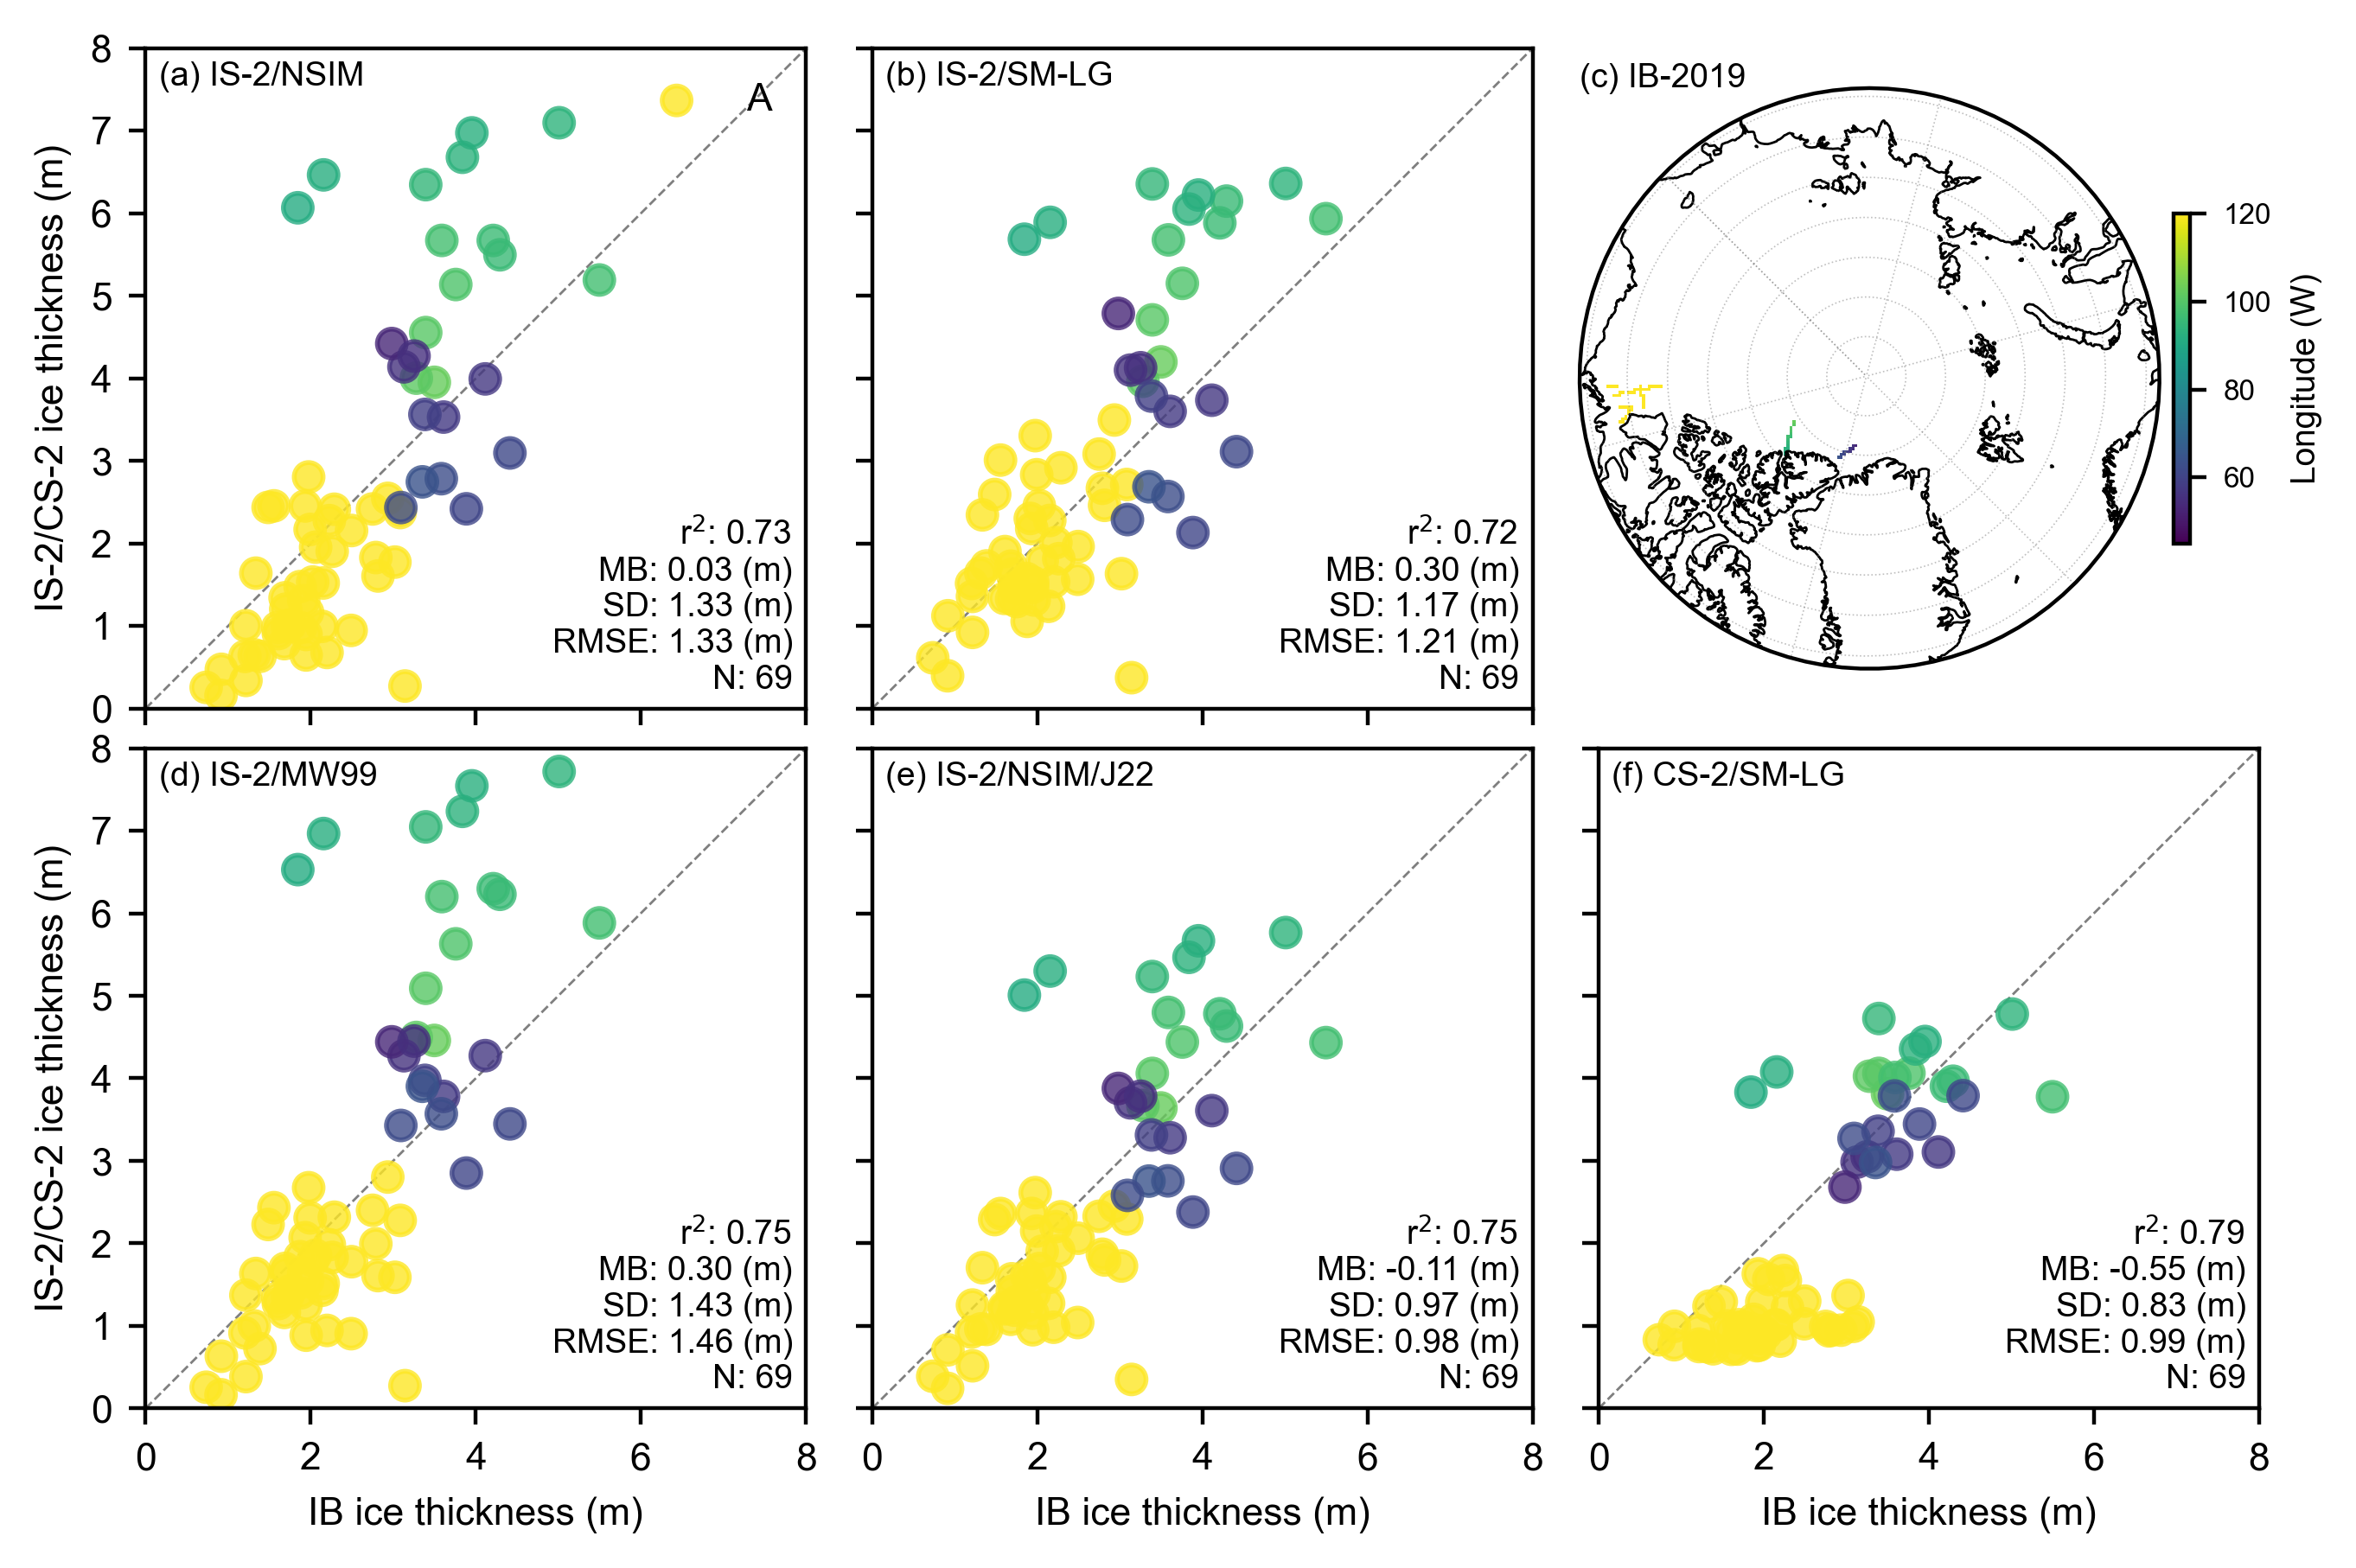

In [43]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

fig = plt.figure(figsize=(6.8, 6.8*0.65))
gs = fig.add_gridspec(2, 3, hspace=0.06, wspace=0.04)

axes = []
for i in range(2):
    for j in range(3):
        if i == 0 and j == 2:
            # Create the cartopy map in the third position
            ax = fig.add_subplot(gs[i, j], projection=ccrs.NorthPolarStereo(central_longitude=-45))
        else:
            ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

panel_labels = ['(a) IS-2/NSIM', '(b) IS-2/SM-LG', '(c)', '(d) IS-2/MW99', '(e) IS-2/NSIM/J22', '(f) CS-2/SM-LG']

#panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']  # Panel labels

# Configure the cartopy map in the third subplot
map_ax = axes[2]
map_ax.set_extent([-180, 180, 68, 90], crs=ccrs.PlateCarree())
map_ax.coastlines(resolution='50m', color='black', linewidth=0.5)
map_ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5, linestyle=':')

# Add a circular boundary for the polar plot
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
map_ax.set_boundary(circle, transform=map_ax.transAxes)

# Plot IceBird flight tracks or data locations
# Example: Plot the locations of the IceBird measurements
im = map_ax.pcolormesh(
    dataset.x, 
    dataset.y, 
    -1.*dataset.lon.where(np.isfinite(dataset.sea_ice_thickness_mean.mean(dim='time'))), 
    transform=ccrs.NorthPolarStereo(central_longitude=-45),
    cmap='viridis',
    vmin=45, 
    vmax=120  # Adjust the range as needed
)
cbar = plt.colorbar(im, ax=map_ax, orientation='vertical', pad=0.02, shrink=0.5)
cbar.set_label('Longitude (W)', fontsize=7)
cbar.ax.tick_params(labelsize=6)

# Add panel label
map_ax.annotate(f"{panel_labels[2]} IB-2019", xy=(0.0, 0.99), 
                xycoords='axes fraction', 
                horizontalalignment='left', 
                verticalalignment='bottom',
                fontsize=7)



# Process the other subplots as before
for i, option in enumerate(variables_ice):
    if i < 2:
        ax_idx = i
    else:
        ax_idx = i + 1  # Skip the map subplot
    
    ax = axes[ax_idx]
    im = ax.scatter(validation_results[option]['IB_comps'], validation_results[option]['IS2_comps'], 
                   c=validation_results[option]['IB_lon'], alpha=0.8, vmin=45, vmax=120, label='A')

    # Retrieve validation results for the current option
    r_str = validation_results[option]['r_str']
    mb_str = validation_results[option]['mb_str']
    sd_str = validation_results[option]['sd_str']
    n_str = str(len(validation_results[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results[option]['rmse']

    # Annotate the plot with statistics
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", 
                color='k', xy=(0.98, 0.02), xycoords='axes fraction', 
                horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[ax_idx]} ", xy=(0.02, 0.98), 
                xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (ax_idx == 0):
        ax.legend(frameon=False, loc="upper right")
    if (ax_idx == 0) or (ax_idx == 3):
        ax.set_ylabel('IS-2/CS-2 ice thickness (m)')
    else:
        ax.set_yticklabels('')
    if ax_idx >= 3:
        ax.set_xlabel('IB ice thickness (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 8])
    ax.set_ylim([0, 8])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.09)  # Adjust these values to reduce whitespace

plt.savefig('./figs/IB_scatter_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km.pdf', dpi=300)
plt.show()

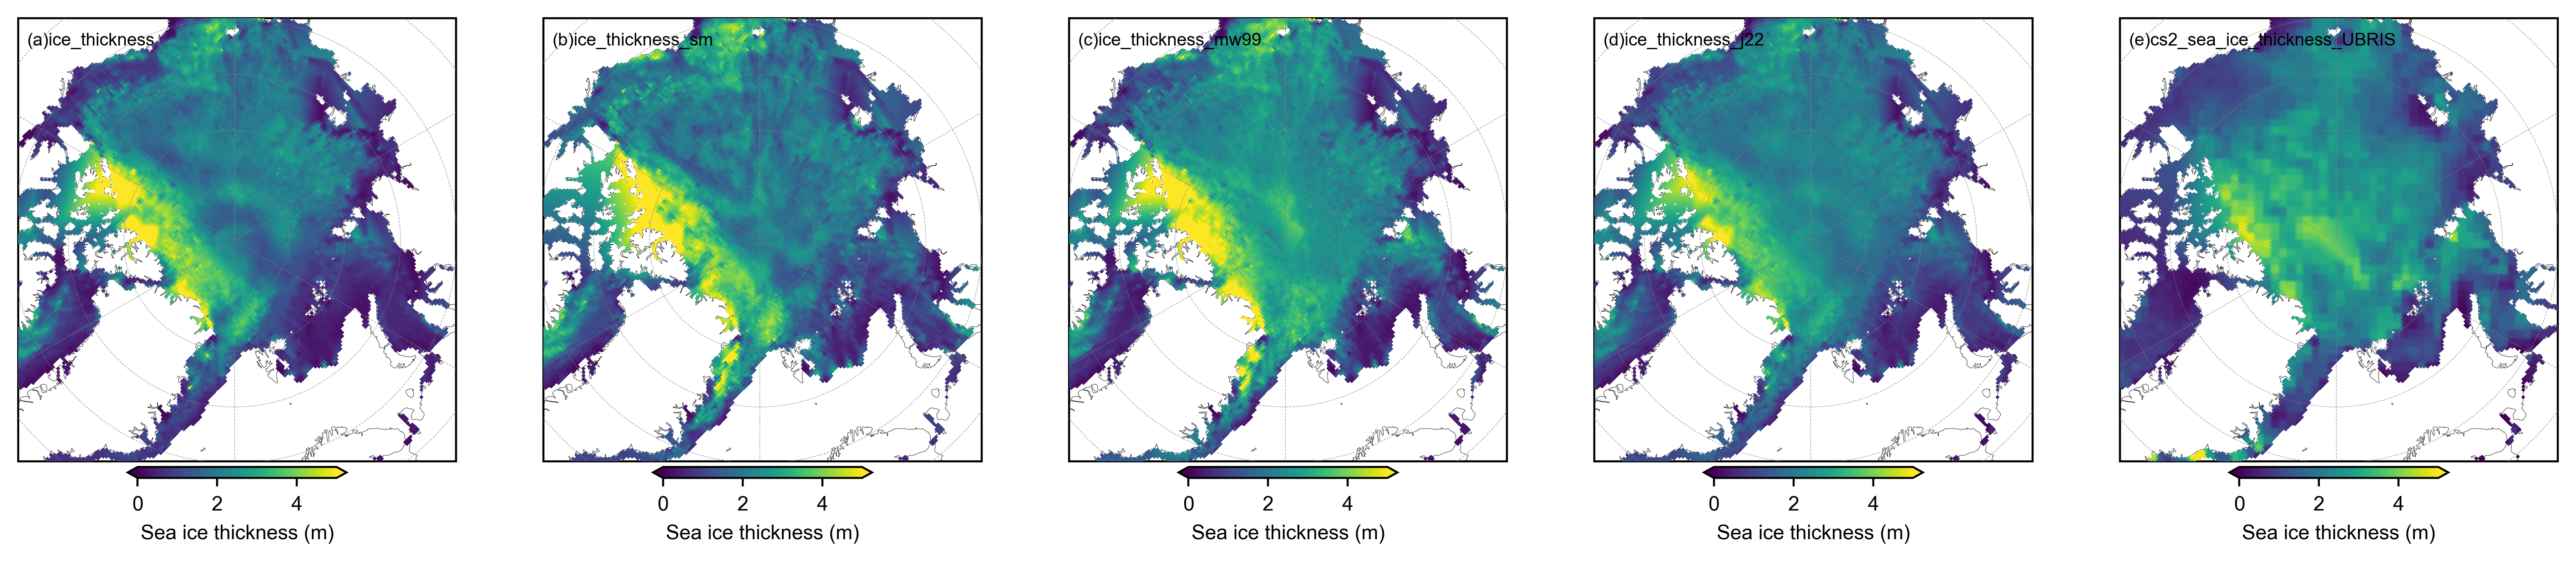

<Figure size 1280x960 with 0 Axes>

In [39]:


fig_width=6.8
fig_height=5.4

# Define the figure and axes
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 4), subplot_kw={'projection': ccrs.NorthPolarStereo()})
i=0
# Iterate over each variable and plot it
for ax, var in zip(axes, variables_ice):
    IS2SITMOGR4_v3[var].plot(ax=ax, x="longitude", y="latitude", transform=ccrs.PlateCarree(),
                        cmap="viridis", zorder=3, add_labels=False,
                        cbar_kwargs={'pad':0.01,'shrink': 0.5,'extend':'both', 
                                  'label':'Sea ice thickness (m)', 'location':'bottom'},
                        vmin=0, vmax=5)
    ax.coastlines(linewidth=0.15, color='black', zorder=2)
    #ax.add_feature(cfeature.LAND, color='0.95', zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=3)
    ax.set_extent([-179, 179, 70, 90], crs=ccrs.PlateCarree())
    ax.text(0.02, 0.93, panel_labels[i]+''+var, transform=ax.transAxes, fontsize=7, va='bottom', ha='left')
    ax.set_title('', fontsize=8)
    i+=1
#plt.subplots_adjust(wspace=0.01) 
plt.savefig('./figs/maps_IB_sea_ice_thickness_'+str(grid_size)+'km.png', dpi=300, facecolor="white")
plt.show()
plt.close()

# Adjust layout
plt.tight_layout()
plt.show()

In [40]:




# Initialize a dictionary to store validation results
validation_results_snow = {}

# Calculate statistics and generate scatter plots for each variable
for var in variables_snow:
    # Calculate statistics
    IS2_var = IS2SITMOGR4_v3[var]
    IB_var = dataset['snow_thickness_'+ib_agg_str].mean(dim='time')
    IB_lon = dataset['lon']    
    valid_mask = ~np.isnan(IS2_var.values) & ~np.isnan(IB_var.values)
    IB_lon=IB_lon.where(valid_mask).values.flatten()[~np.isnan(IB_var.where(valid_mask).values.flatten())]*-1.
    IB_comps=IB_var.where(valid_mask).values.flatten()[~np.isnan(IB_var.where(valid_mask).values.flatten())]
    IS2_comps=IS2_var.where(valid_mask).values.flatten()[~np.isnan(IS2_var.where(valid_mask).values.flatten())]

    # Correlation Coeff
    correlation = '%.02f' % (np.corrcoef(IS2_comps, IB_comps)[0, 1])
    # Calculate mean bias
    mean_bias = '%.02f' % (np.mean(IS2_comps - IB_comps))
    # Calculate standard dev of differences
    std_dev = '%.02f' % (np.std(IS2_comps - IB_comps))
    # Calculate RMSE    
    rmse = '%.02f' % (np.sqrt(np.mean((IS2_comps - IB_comps) ** 2)))
    
    # Store results
    validation_results_snow[var] = {
        'r_str': correlation, 'mb_str': mean_bias, 'sd_str': std_dev, 'rmse': rmse, 
        'IB_comps': IB_comps, 'IS2_comps': IS2_comps, 'IB_lon': IB_lon
    }

# Print validation results
print(validation_results_snow)

{'snow_depth': {'r_str': '0.73', 'mb_str': '0.05', 'sd_str': '0.08', 'rmse': '0.10', 'IB_comps': array([0.06057073, 0.06105634, 0.09536311, 0.11553236, 0.06754043,
       0.30673701, 0.19219818, 0.19971608, 0.17024907, 0.23391877,
       0.26220036, 0.12750907, 0.17008325, 0.17484917, 0.10289436,
       0.30978738, 0.09542142, 0.0897806 , 0.14715854, 0.15417748,
       0.22641294, 0.20967575, 0.04853597, 0.06319857, 0.07595014,
       0.13746001, 0.23879097, 0.20610597, 0.12469022, 0.18559015,
       0.07945059, 0.10895898, 0.07548158, 0.06619574, 0.07725245,
       0.24790862, 0.06666562, 0.07637328, 0.09319101, 0.06116864,
       0.05081544, 0.06449741, 0.04769962, 0.05296721, 0.45795119,
       0.33064069, 0.36622978, 0.37998228, 0.35620119, 0.34690287,
       0.31718276, 0.33131602, 0.35685806, 0.37236173, 0.30807644,
       0.35553257, 0.34827531, 0.42601264, 0.31349524, 0.32759419,
       0.40773475, 0.22747368, 0.29064071, 0.32335714, 0.43523337,
       0.28529025, 0.29525694, 0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


snow_depth
snow_depth_sm
snow_depth_mw99


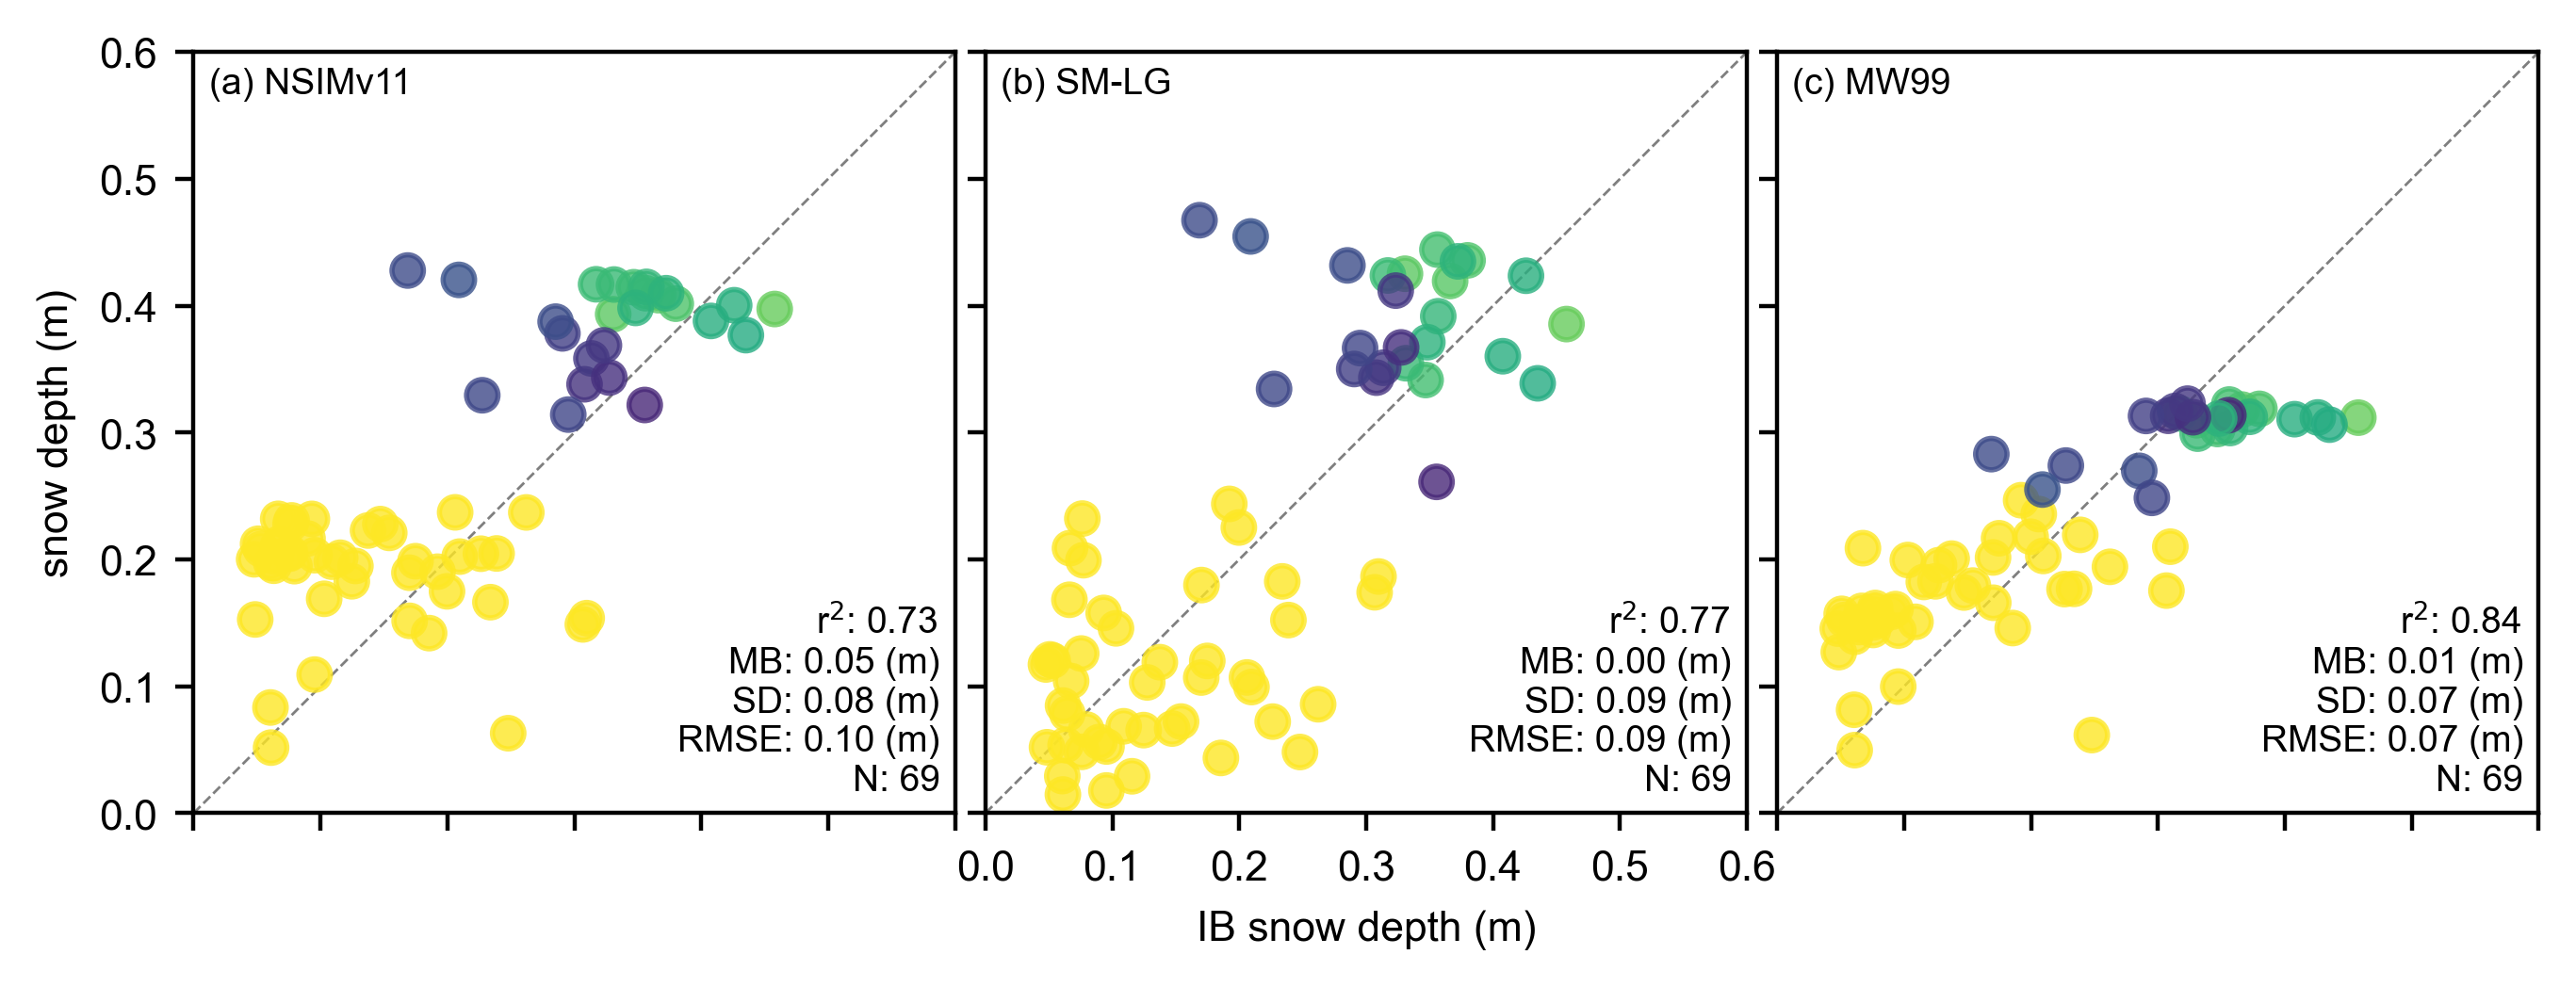

In [41]:
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

snow_labels=['NSIMv11', 'SM-LG', 'MW99']
# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 6.8*0.36), gridspec_kw={'hspace': 0.06, 'wspace': 0.04})  # Adjust hspace and wspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)']  # Panel labels


for i, option in enumerate(variables_snow):
    print(option)
    ax = axes[i]

    ax.scatter(validation_results_snow[option]['IB_comps'], validation_results_snow[option]['IS2_comps'], c=validation_results_snow[option]['IB_lon'], alpha=0.8, vmin=45, vmax=120)

    # Retrieve validation results for the current option
    r_str= validation_results_snow[option]['r_str']
    mb_str = validation_results_snow[option]['mb_str']
    sd_str = validation_results_snow[option]['sd_str']
    n_str =  str(len(validation_results_snow[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results_snow[option]['rmse']

    # Annotate the plot with RMSE, mean bias, and standard deviation
    #ax.annotate(f"A  r$^2$: {r_str_a}  MB: {mb_str_a} (m) SD: {sd_str_a} (m)  RMSE: {rmse_a:.02f} (m)", color='b', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"B  r$^2$: {r_str_b}  MB: {mb_str_b} (m) SD: {sd_str_b} (m)  RMSE: {rmse_b:.02f} (m)", color='tab:red', xy=(0.02, 0.92), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"D  r$^2$: {r_str_d}  MB: {mb_str_d} (m) SD: {sd_str_d} (m)  RMSE: {rmse_d:.02f} (m)", color='tab:orange', xy=(0.02, 0.86), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+snow_labels[i], xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (i==0):
        ax.legend(frameon=False, loc="upper right")
    if (i == 0):
        ax.set_ylabel('snow depth (m)')
    else:
        ax.set_yticklabels('')
    if i == 1:
        ax.set_xlabel('IB snow depth (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 0.6])
    ax.set_ylim([0, 0.6])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.legend()

#plt.tight_layout()
plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.15)  # Adjust these values to reduce whitespace

plt.savefig('./figs/IB_scatter_snow_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km.pdf', dpi=300)
plt.show()

# ... existing code ...

NameError: name 'variables' is not defined

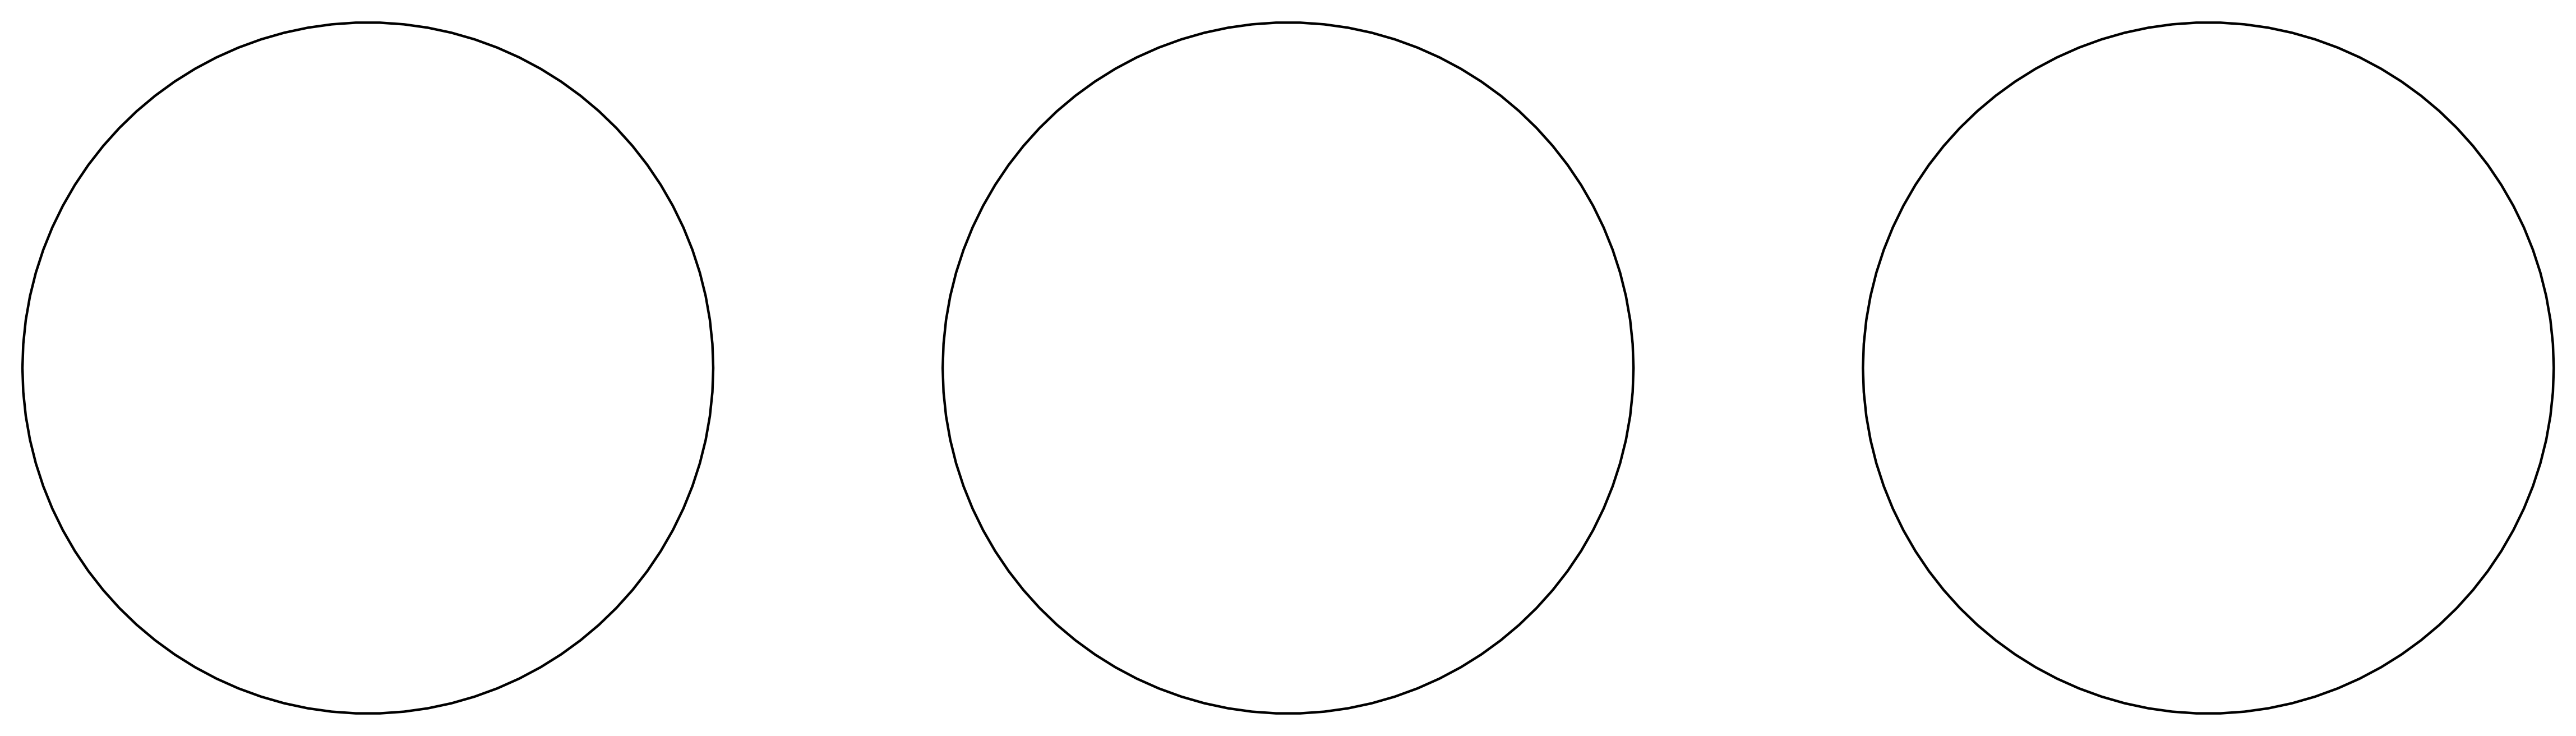

In [42]:


fig_width=6.8
fig_height=5.4

# Define the figure and axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), subplot_kw={'projection': ccrs.NorthPolarStereo()})
i=0
# Iterate over each variable and plot it
for ax, var in zip(axes, variables):
    coarsened_IS2SITMOGR4_v3.sel(time='2019-04-01')[var].plot(ax=ax, x="longitude", y="latitude", transform=ccrs.PlateCarree(),
                        cmap="viridis", zorder=3, add_labels=False,
                        cbar_kwargs={'pad':0.01,'shrink': 0.5,'extend':'both', 
                                  'label':'Snow depth (m)', 'location':'bottom'},
                        vmin=0, vmax=1)
    ax.coastlines(linewidth=0.15, color='black', zorder=2)
    #ax.add_feature(cfeature.LAND, color='0.95', zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=3)
    ax.set_extent([-179, 179, 70, 90], crs=ccrs.PlateCarree())
    ax.text(0.02, 0.93, panel_letters[i]+''+var, transform=ax.transAxes, fontsize=7, va='bottom', ha='left')
    ax.set_title('', fontsize=8)
    i+=1
#plt.subplots_adjust(wspace=0.01) 
plt.savefig('./figs/maps_IB_snow_depth_'+str(grid_size)+'km.png', dpi=300, facecolor="white")
plt.show()
plt.close()

# Adjust layout
plt.tight_layout()
plt.show()

In [286]:
coarsened_IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 57, y: 56, x: 38)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.75e+06 -3.55e+06 ... 3.65e+06
  * y                               (y) float32 5.75e+06 5.55e+06 ... -5.25e+06
    latitude                        (y, x) float32 31.96 32.73 ... 36.19 35.36
    longitude                       (y, x) float32 168.1 166.7 ... -11.69 -10.19
Data variables: (12/29)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    ...                              ...
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 56, 38), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... nan nan
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...